priority false negative which ll cost more

In [84]:
import numpy as np
import pandas as pd

In [85]:
df=pd.read_csv('/content/drive/MyDrive/learning_colab_datasets/nearest-earth-objects(1910-2024).csv')

In [86]:
df.head()

,neo_id,name,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,orbiting_body,relative_velocity,miss_distance,is_hazardous
0,2162117,162117 (1998 SD15),19.14,0.394962,0.883161,Earth,71745.401048,5.814362e+07,False
1,2349507,349507 (2008 QY),18.50,0.530341,1.185878,Earth,109949.757148,5.580105e+07,True
2,2455415,455415 (2003 GA),21.45,0.136319,0.304818,Earth,24865.506798,6.720689e+07,False
3,3132126,(2002 PB),20.63,0.198863,0.444672,Earth,78890.076805,3.039644e+07,False
4,3557844,(2011 DW),22.70,0.076658,0.171412,Earth,56036.519484,6.311863e+07,False


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338199 entries, 0 to 338198
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   neo_id                  338199 non-null  int64  
 1   name                    338199 non-null  object 
 2   absolute_magnitude      338171 non-null  float64
 3   estimated_diameter_min  338171 non-null  float64
 4   estimated_diameter_max  338171 non-null  float64
 5   orbiting_body           338199 non-null  object 
 6   relative_velocity       338199 non-null  float64
 7   miss_distance           338199 non-null  float64
 8   is_hazardous            338199 non-null  bool   
dtypes: bool(1), float64(5), int64(1), object(2)
memory usage: 21.0+ MB


In [88]:
df.describe()

,neo_id,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance
count,3.381990e+05,338171.000000,338171.000000,338171.000000,338199.000000,3.381990e+05
mean,1.759939e+07,22.932525,0.157812,0.352878,51060.662908,4.153535e+07
std,2.287225e+07,2.911216,0.313885,0.701869,26399.238435,2.077399e+07
min,2.000433e+06,9.250000,0.000511,0.001143,203.346433,6.745533e+03
25%,3.373980e+06,20.740000,0.025384,0.056760,30712.031471,2.494540e+07
50%,3.742127e+06,22.800000,0.073207,0.163697,47560.465474,4.332674e+07
75%,5.405374e+07,25.100000,0.189041,0.422708,66673.820614,5.933961e+07
max,5.446281e+07,33.580000,37.545248,83.953727,291781.106613,7.479865e+07


In [89]:
df['is_hazardous'].value_counts()

,count
is_hazardous,
False,295037
True,43162


class imbalance

In [90]:
df.isnull().sum()

,0
neo_id,0
name,0
absolute_magnitude,28
estimated_diameter_min,28
estimated_diameter_max,28
orbiting_body,0
relative_velocity,0
miss_distance,0
is_hazardous,0


In [91]:
import seaborn as sns
from matplotlib import pyplot as plt

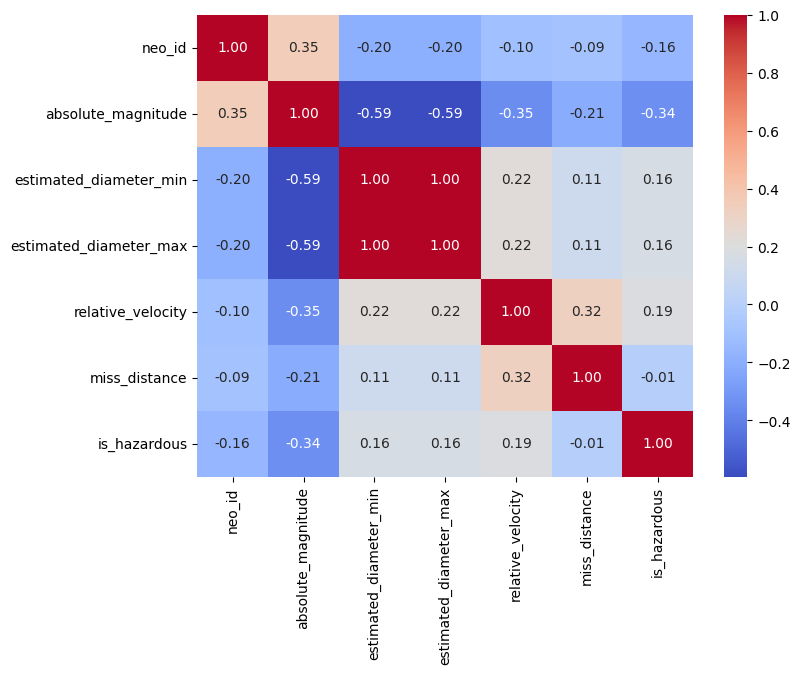

In [92]:
corr=df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")
plt.show()


In [93]:
df.drop('neo_id',axis=1,inplace=True)
df.drop('name',axis=1,inplace=True)


In [94]:
df['orbiting_body'].value_counts()

,count
orbiting_body,
Earth,338199


In [95]:
df.drop('orbiting_body',inplace=True,axis=1)

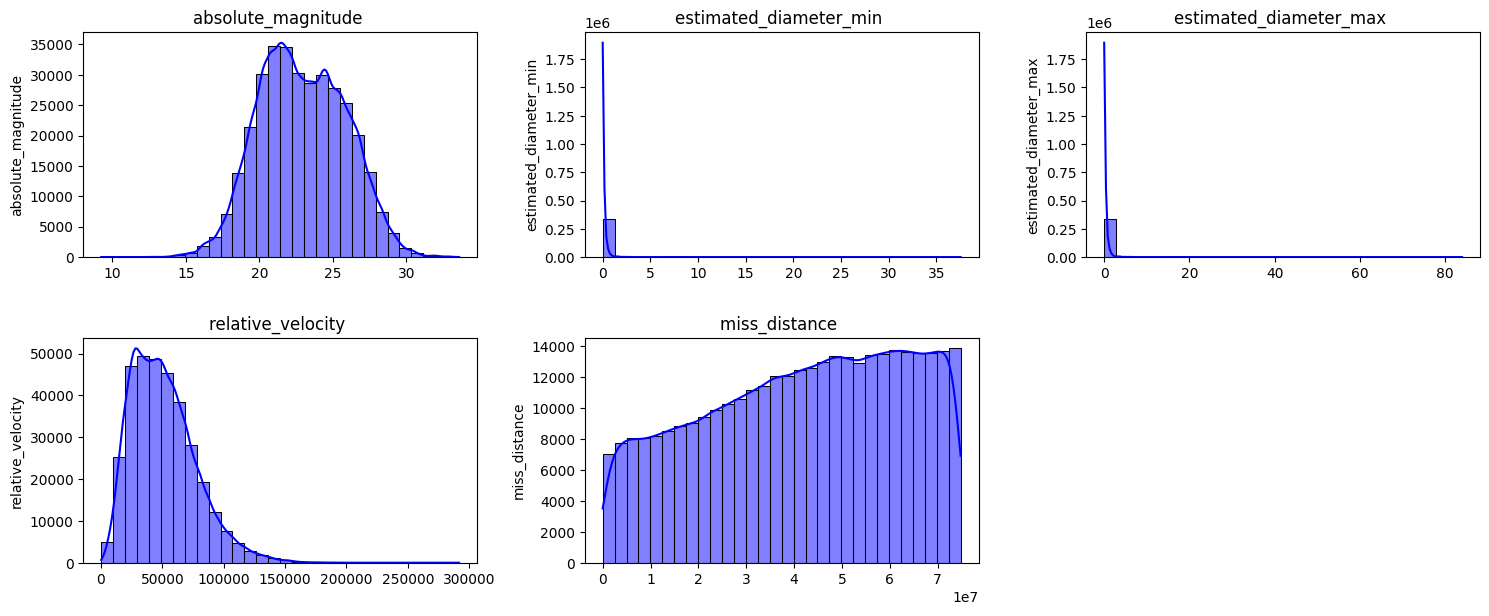

In [96]:
plt.figure(figsize=(15, 15))
for i, feature in enumerate(df.select_dtypes(include='number').columns):
    plt.subplot(5, 3, i+1)
    sns.histplot(data=df, x=feature, bins=30, kde=True, color='blue')
    plt.title(f'{feature} ')
    plt.xlabel(' ')
    plt.ylabel(feature)
plt.tight_layout()


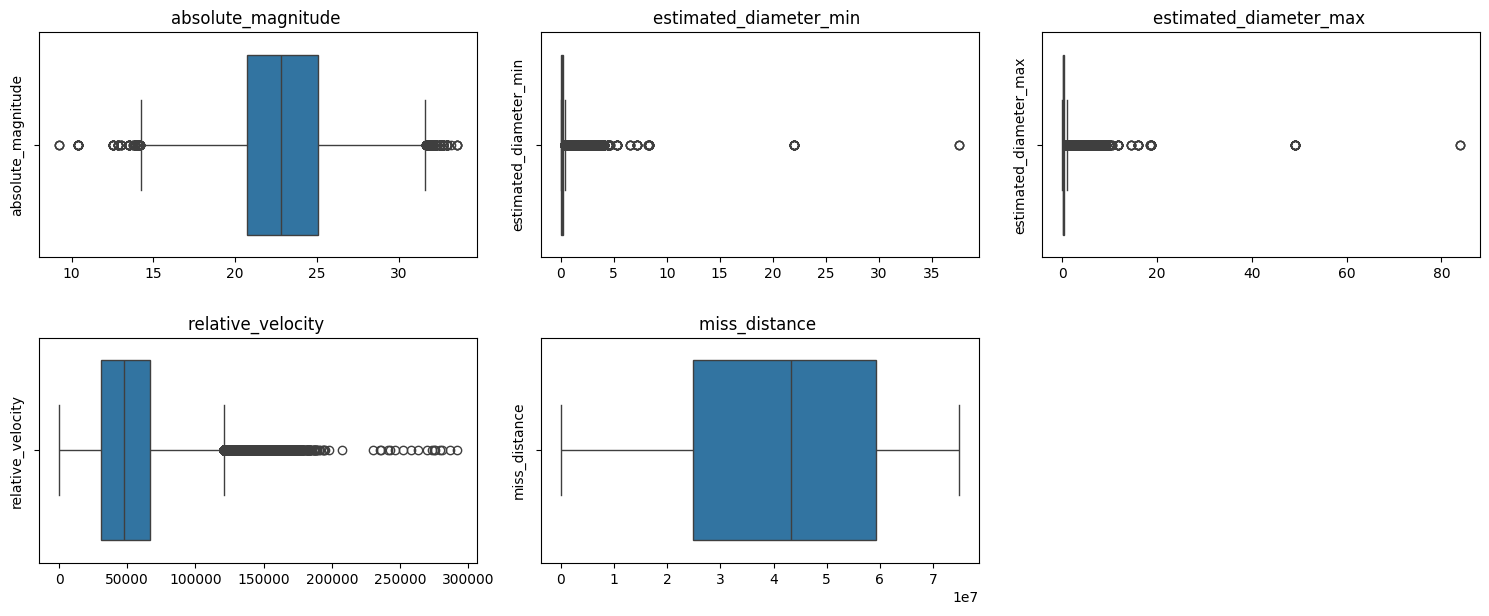

In [97]:
plt.figure(figsize=(15, 15))
for i, feature in enumerate(df.select_dtypes(include='number').columns):
    plt.subplot(5, 3, i+1)
    sns.boxplot(data=df, x=feature)
    plt.title(f'{feature} ')
    plt.xlabel(' ')
    plt.ylabel(feature)
plt.tight_layout()

In [98]:
df.dropna(inplace=True)

In [99]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [100]:
x=df.drop('is_hazardous',axis=1)
y=df['is_hazardous']

In [101]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=55,stratify=y)

In [102]:
Rf=RandomForestClassifier(random_state=55  , n_estimators=100,n_jobs=-1)
Rf.fit(x_train,y_train)
pred=Rf.predict(x_test)
print('classification reprot')
print('---------------------------------------')
print(classification_report(y_test,pred))
print('---------------------------------------')
print('confusion matrix')
print('---------------------------------------')
print(confusion_matrix(y_test,pred))


classification reprot
---------------------------------------
              precision    recall  f1-score   support

       False       0.94      0.97      0.95     59002
        True       0.71      0.59      0.65      8633

    accuracy                           0.92     67635
   macro avg       0.83      0.78      0.80     67635
weighted avg       0.91      0.92      0.91     67635

---------------------------------------
confusion matrix
---------------------------------------
[[56942  2060]
 [ 3523  5110]]


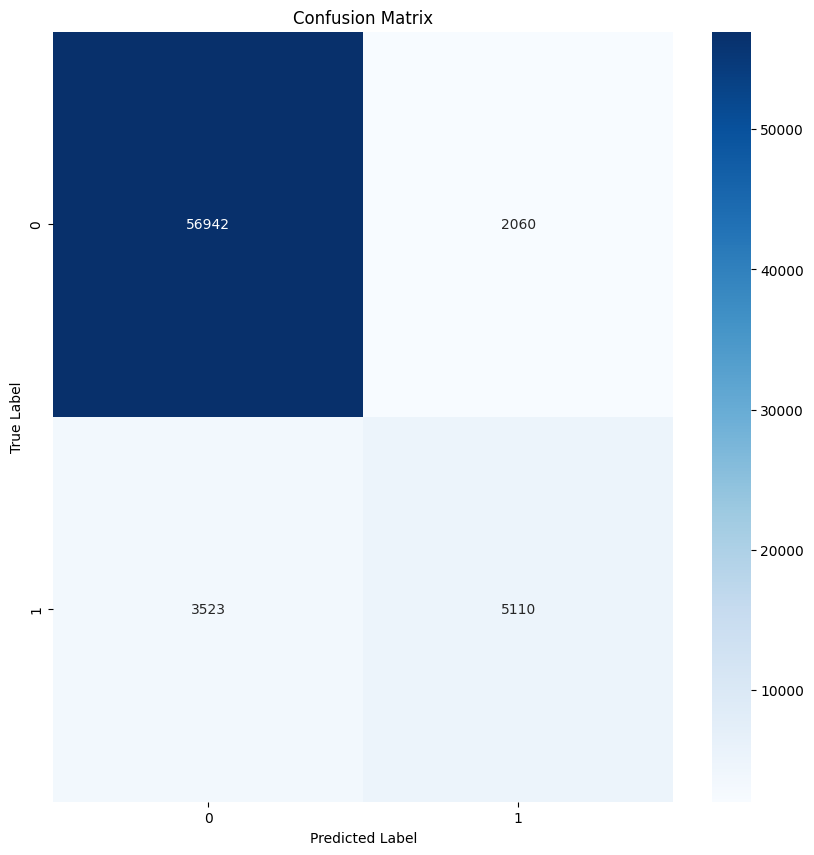

In [103]:
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(confusion_matrix(y_test, pred), annot=True, cmap='Blues', ax=ax, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

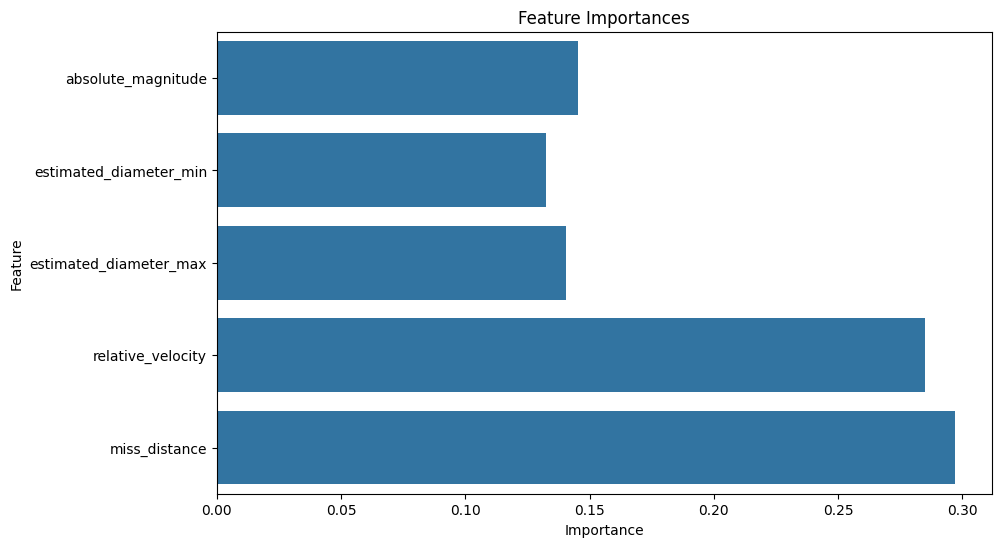

In [104]:
feature_importances = Rf.feature_importances_
feature_names = x.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_names)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [105]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(x_train, y_train)
pred = rf.predict(x_test)
print('Classification Report:')
print(classification_report(y_test, pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, pred))


Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.97      0.95     59002
        True       0.72      0.58      0.64      8633

    accuracy                           0.92     67635
   macro avg       0.83      0.77      0.80     67635
weighted avg       0.91      0.92      0.91     67635

Confusion Matrix:
[[57108  1894]
 [ 3666  4967]]


In [106]:
y_prob = rf.predict_proba(x_test)[:, 1]


In [107]:

for t in [0.45, 0.40, 0.35, 0.30]:
    y_pred_t = (y_prob >= t).astype(int)


In [108]:
print('Classification Report:')
print(classification_report(y_test, y_pred_t))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_t))

Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.92      0.94     59002
        True       0.60      0.77      0.68      8633

    accuracy                           0.91     67635
   macro avg       0.78      0.85      0.81     67635
weighted avg       0.92      0.91      0.91     67635

Confusion Matrix:
[[54576  4426]
 [ 1963  6670]]


In [109]:
fn_mask = (y_test == 1) & (y_pred_t == 0)
fn_data = x_test[fn_mask] #missed


In [110]:
tp_mask = (y_test == 1) & (y_pred_t == 1)
tp_data = x_test[tp_mask] #correctly predicted


In [111]:
fn_data.describe()



,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance
count,1963.000000,1963.000000,1963.000000,1963.000000,1.963000e+03
mean,20.279893,0.286603,0.640863,65259.607057,4.801001e+07
std,1.274892,0.249339,0.557539,25756.788760,1.694859e+07
min,14.400000,0.083283,0.186226,8867.085734,9.049614e+06
25%,19.475000,0.146068,0.326618,47203.477948,3.446102e+07
50%,20.450000,0.216050,0.483103,63361.831940,4.920799e+07
75%,21.300000,0.338498,0.756905,81672.314632,6.242010e+07
max,22.520000,3.503926,7.835018,163772.388896,7.479095e+07


In [112]:
tp_data.describe()

,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance
count,6670.000000,6670.000000,6670.000000,6670.000000,6.670000e+03
mean,20.307918,0.296107,0.662116,63821.153017,3.958055e+07
std,1.358890,0.302197,0.675732,28232.951529,2.144888e+07
min,14.100000,0.083283,0.186226,9133.217919,2.332596e+05
25%,19.640000,0.142087,0.317717,42695.481606,2.014096e+07
50%,20.630000,0.198863,0.444672,59367.704287,4.100602e+07
75%,21.360000,0.313729,0.701520,80455.513667,5.839629e+07
max,22.520000,4.023046,8.995804,194676.462159,7.478037e+07


In [113]:
df_copy=pd.read_csv('/content/drive/MyDrive/learning_colab_datasets/nearest-earth-objects(1910-2024).csv')

In [114]:
df_copy.drop(["neo_id",	"name" ,"orbiting_body"],axis=1,inplace=True)

In [115]:
df_copy.dropna()

,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance,is_hazardous
0,19.140,0.394962,0.883161,71745.401048,5.814362e+07,False
1,18.500,0.530341,1.185878,109949.757148,5.580105e+07,True
2,21.450,0.136319,0.304818,24865.506798,6.720689e+07,False
3,20.630,0.198863,0.444672,78890.076805,3.039644e+07,False
4,22.700,0.076658,0.171412,56036.519484,6.311863e+07,False
...,...,...,...,...,...,...
338194,28.580,0.005112,0.011430,56646.985988,6.406548e+07,False
338195,28.690,0.004859,0.010865,21130.768947,2.948883e+07,False
338196,21.919,0.109839,0.245607,11832.041031,5.346078e+07,False
338197,23.887,0.044377,0.099229,56198.382733,5.184742e+06,False


In [116]:
df_copy['estimated_diameter_mean'] = (df_copy['estimated_diameter_min'] + df_copy['estimated_diameter_max']) / 2
df_copy.drop(['estimated_diameter_min', 'estimated_diameter_max'], axis=1, inplace=True)


In [117]:

df_copy['kinetic_proxy'] = (df_copy['estimated_diameter_mean'] * df_copy['relative_velocity'])
df_copy['size_to_distance'] = (df_copy['estimated_diameter_mean'] / df_copy['miss_distance'])


In [118]:
df_copy

,absolute_magnitude,relative_velocity,miss_distance,is_hazardous,estimated_diameter_mean,kinetic_proxy,size_to_distance
0,19.140,71745.401048,5.814362e+07,False,0.639061,45849.719644,1.099108e-08
1,18.500,109949.757148,5.580105e+07,True,0.858109,94348.910896,1.537801e-08
2,21.450,24865.506798,6.720689e+07,False,0.220568,5484.536513,3.281926e-09
3,20.630,78890.076805,3.039644e+07,False,0.321768,25384.288542,1.058571e-08
4,22.700,56036.519484,6.311863e+07,False,0.124035,6950.463542,1.965102e-09
...,...,...,...,...,...,...,...
338194,28.580,56646.985988,6.406548e+07,False,0.008271,468.510604,1.290977e-10
338195,28.690,21130.768947,2.948883e+07,False,0.007862,166.133770,2.666153e-10
338196,21.919,11832.041031,5.346078e+07,False,0.177723,2102.820895,3.324354e-09
338197,23.887,56198.382733,5.184742e+06,False,0.071803,4035.212728,1.384890e-08


In [119]:

X = df_copy.drop(['is_hazardous'], axis=1)
y = df_copy['is_hazardous']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
   n_jobs=-1
)
clf.fit(X_train, y_train)


#y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

for t in [0.45, 0.40, 0.35, 0.30]:
    y_pred_t = (y_prob >= t).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
print(f"TP: {tp}, FN: {fn}, FP: {fp}, TN: {tn}")

# Classification report
print(classification_report(y_test, y_pred_t))


feat_imp = pd.Series(clf.feature_importances_, index=X.columns)
print("Top features:\n", feat_imp.sort_values(ascending=False).head(10))


TP: 6448, FN: 2184, FP: 4776, TN: 54232
              precision    recall  f1-score   support

       False       0.96      0.92      0.94     59008
        True       0.57      0.75      0.65      8632

    accuracy                           0.90     67640
   macro avg       0.77      0.83      0.79     67640
weighted avg       0.91      0.90      0.90     67640

Top features:
 absolute_magnitude         0.271934
estimated_diameter_mean    0.220669
kinetic_proxy              0.184164
size_to_distance           0.125941
relative_velocity          0.102928
miss_distance              0.094364
dtype: float64
